# Hand Gesture Classification

## Imports and Setup

In [ ]:
import time
import pickle

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

from scipy.stats import randint, loguniform, uniform
from xgboost import XGBClassifier


def select_best_model(
    results_df: pd.DataFrame,
    primary_metric: str = "f1_macro",
    higher_is_better: bool = True,
    tie_breaker_metric: str = "accuracy",
    tie_breaker_higher_is_better: bool = True,
) :
    if primary_metric not in results_df.columns:
        raise ValueError(f"primary_metric '{primary_metric}' missing from results_df")

    sort_cols = [primary_metric]
    ascending = [not higher_is_better]
    if tie_breaker_metric and tie_breaker_metric in results_df.columns and tie_breaker_metric != primary_metric:
        sort_cols.append(tie_breaker_metric)
        ascending.append(not tie_breaker_higher_is_better)

    ranked = results_df.sort_values(sort_cols, ascending=ascending).reset_index(drop=True)
    return ranked.iloc[0]


SEED = 42
np.random.seed(SEED)
print("Imports loaded.")

Imports loaded.


## Data Loading and Checks

In [5]:
df = pd.read_csv("hand_landmarks_data.csv")
print(f"Dataset shape: {df.shape}")
print(f"Samples: {df.shape[0]:,}")
print(f"Base features: {df.shape[1] - 1}")
print(f"Classes: {df['label'].nunique()}")


Dataset shape: (25675, 64)
Samples: 25,675
Base features: 63
Classes: 18


In [6]:
missing_total = int(df.isna().sum().sum())
duplicates = int(df.duplicated().sum())
print(f"Missing values: {missing_total}")
print(f"Duplicate rows: {duplicates}")

if duplicates > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print(f"Dropped duplicates. New shape: {df.shape}")


Missing values: 0
Duplicate rows: 0


label
three2            1653
palm              1649
four              1634
ok                1592
stop_inverted     1567
call              1506
peace_inverted    1497
stop              1482
rock              1458
three             1456
Name: count, dtype: int64

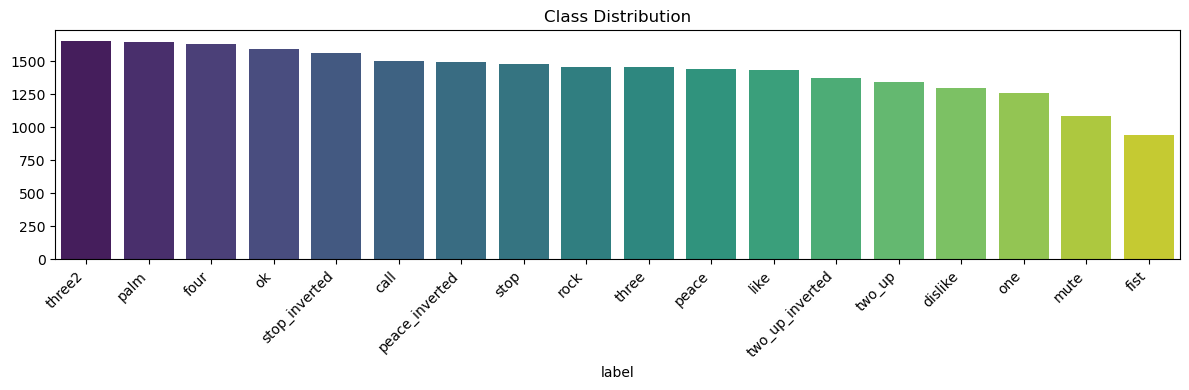

In [7]:
class_counts = df["label"].value_counts().sort_values(ascending=False)
display(class_counts.head(10))

plt.figure(figsize=(12, 4))
sns.barplot(x=class_counts.index, y=class_counts.values, palette="viridis")
plt.title("Class Distribution")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


## Preprocessing

In [ ]:
def normalize_landmarks(df_input):
    out = df_input.copy()
    rows = []
    for _, row in out.iterrows():
        coords = np.array(
            [[row[f"x{i}"], row[f"y{i}"], row[f"z{i}"]] for i in range(1, 22)],
            dtype=np.float32,
        )

        wrist = coords[0].copy()
        coords -= wrist

        scale = np.sqrt(coords[12, 0] ** 2 + coords[12, 1] ** 2)
        if scale < 1e-6:
            scale = 1e-6
        coords[:, 0] /= scale
        coords[:, 1] /= scale

        rows.append(coords.reshape(-1))

    feature_cols_local = [f"{axis}{i}" for i in range(1, 22) for axis in ("x", "y", "z")]
    out_features = pd.DataFrame(rows, columns=feature_cols_local, index=out.index)
    out_features["label"] = out["label"].values
    return out_features


df_normalized = normalize_landmarks(df)
print(f"Normalized dataframe shape: {df_normalized.shape}")


Normalized dataframe shape: (25675, 64)


In [9]:
le = LabelEncoder()
df_normalized["label_encoded"] = le.fit_transform(df_normalized["label"])

feature_cols = [c for c in df_normalized.columns if c not in ["label", "label_encoded"]]
X = df_normalized[feature_cols].values
y = df_normalized["label_encoded"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

x_indices = [feature_cols.index(f"x{i}") for i in range(1, 22)]
y_indices = [feature_cols.index(f"y{i}") for i in range(1, 22)]
xy_indices = sorted(x_indices + y_indices)

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[:, xy_indices] = scaler.fit_transform(X_train[:, xy_indices])
X_test_scaled[:, xy_indices] = scaler.transform(X_test[:, xy_indices])

print(f"Train: {X_train_scaled.shape}, Test: {X_test_scaled.shape}")


Train: (20540, 63), Test: (5135, 63)


## Feature Engineering

In [10]:
def engineer_features(X_data, feature_names):
    def get_lm(landmark_idx):
        col_x = feature_names.index(f"x{landmark_idx + 1}")
        col_y = feature_names.index(f"y{landmark_idx + 1}")
        col_z = feature_names.index(f"z{landmark_idx + 1}")
        return X_data[:, col_x], X_data[:, col_y], X_data[:, col_z]

    def dist_3d(a, b):
        ax, ay, az = get_lm(a)
        bx, by, bz = get_lm(b)
        return np.sqrt((ax - bx) ** 2 + (ay - by) ** 2 + (az - bz) ** 2)

    new_feats = {}
    tips = [4, 8, 12, 16, 20]
    tip_names = ["thumb", "index", "middle", "ring", "pinky"]
    mcps = [1, 5, 9, 13, 17]

    for i in range(len(tips)):
        for j in range(i + 1, len(tips)):
            new_feats[f"dist_{tip_names[i]}_{tip_names[j]}"] = dist_3d(tips[i], tips[j])

    for tip, tname in zip(tips, tip_names):
        new_feats[f"len_{tname}"] = dist_3d(0, tip)

    for i in range(len(tips)):
        for j in range(i + 1, len(tips)):
            a = new_feats[f"len_{tip_names[i]}"]
            b = new_feats[f"len_{tip_names[j]}"]
            new_feats[f"ratio_{tip_names[i]}_{tip_names[j]}"] = a / (b + 1e-8)

    for tip, mcp, tname in zip(tips, mcps, tip_names):
        tip_mcp = dist_3d(tip, mcp)
        finger_len = new_feats[f"len_{tname}"]
        new_feats[f"curl_{tname}"] = tip_mcp / (finger_len + 1e-8)

    new_feat_array = np.column_stack(list(new_feats.values()))
    new_feat_names = list(new_feats.keys())
    X_aug = np.hstack([X_data, new_feat_array])
    return X_aug, feature_names + new_feat_names


X_train_eng, feat_names_eng = engineer_features(X_train_scaled, feature_cols)
X_test_eng, _ = engineer_features(X_test_scaled, feature_cols)

print(f"Base features: {X_train_scaled.shape[1]}")
print(f"Engineered features: {X_train_eng.shape[1] - X_train_scaled.shape[1]}")
print(f"Total features: {X_train_eng.shape[1]}")


Base features: 63
Engineered features: 30
Total features: 93


## Model Training

In [12]:
def train_and_evaluate(
    model_key,
    name,
    model,
    param_dist,
    X_tr,
    X_te,
    y_tr,
    y_te,
    feature_names,
    label_encoder,
    n_iter=20,
    cv=5,
):
    del feature_names, label_encoder

    print(f"\n{'=' * 60}")
    print(f"Training: {name}")
    print(f"{'=' * 60}")

    search = RandomizedSearchCV(
        estimator=model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring="f1_macro",
        cv=StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED),
        random_state=SEED,
        n_jobs=-1,
        verbose=0,
    )

    start_time = time.time()
    search.fit(X_tr, y_tr)
    train_time = time.time() - start_time

    best_model = search.best_estimator_
    y_pred = best_model.predict(X_te)

    metrics = {
        "accuracy": accuracy_score(y_te, y_pred),
        "precision_macro": precision_score(y_te, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_te, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_te, y_pred, average="macro", zero_division=0),
        "cv_f1_macro": float(search.best_score_),
        "cv_f1_std": float(search.cv_results_["std_test_score"][search.best_index_]),
        "train_time_seconds": float(train_time),
    }

    print(f"Best params   : {search.best_params_}")
    print(f"CV F1 (macro) : {metrics['cv_f1_macro']:.4f}")
    print(f"CV F1 std     : {metrics['cv_f1_std']:.4f}")
    print(f"Test Accuracy : {metrics['accuracy']:.4f}")
    print(f"Test F1       : {metrics['f1_macro']:.4f}")
    print(f"Train time    : {metrics['train_time_seconds']:.1f}s")

    return {
        "model_key": model_key,
        "name": name,
        "model": best_model,
        "y_pred": y_pred,
        "accuracy": metrics["accuracy"],
        "precision": metrics["precision_macro"],
        "recall": metrics["recall_macro"],
        "f1": metrics["f1_macro"],
        "cv_f1": metrics["cv_f1_macro"],
        "cv_f1_std": metrics["cv_f1_std"],
        "train_time": metrics["train_time_seconds"],
        "best_params": search.best_params_,
        "run_id": "",
        "run_name": "",
        "model_uri": "",
    }

In [ ]:
results = {}

rf_params = {
    "n_estimators": randint(100, 801),
    "max_depth": [None] + list(range(8, 41)),
    "min_samples_split": randint(2, 21),
    "min_samples_leaf": randint(1, 8),
    "max_features": ["sqrt", "log2", None],
    "bootstrap": [True, False],
}
svm_params = {
    "C": loguniform(1e-2, 1e2),
    "gamma": loguniform(1e-4, 1e0),
    "kernel": ["rbf"],
}
knn_params = {
    "n_neighbors": randint(3, 31),
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan", "minkowski"],
    "p": [1, 2],
}
xgb_params = {
    "n_estimators": randint(120, 801),
    "max_depth": randint(3, 13),
    "learning_rate": loguniform(1e-3, 3e-1),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_weight": randint(1, 10),
    "reg_alpha": loguniform(1e-4, 1.0),
    "reg_lambda": loguniform(1e-2, 10.0),
}

results["RF"] = train_and_evaluate(
    "RF",
    "Random Forest",
    RandomForestClassifier(random_state=SEED),
    rf_params,
    X_train_eng,
    X_test_eng,
    y_train,
    y_test,
    feat_names_eng,
    le,
    n_iter=20,
)

results["SVM"] = train_and_evaluate(
    "SVM",
    "SVM (RBF)",
    SVC(random_state=SEED),
    svm_params,
    X_train_eng,
    X_test_eng,
    y_train,
    y_test,
    feat_names_eng,
    le,
    n_iter=15,
)

results["KNN"] = train_and_evaluate(
    "KNN",
    "K-Nearest Neighbors",
    KNeighborsClassifier(),
    knn_params,
    X_train_eng,
    X_test_eng,
    y_train,
    y_test,
    feat_names_eng,
    le,
    n_iter=15,
)

results["XGB"] = train_and_evaluate(
    "XGB",
    "XGBoost",
    XGBClassifier(random_state=SEED, eval_metric="mlogloss", verbosity=0),
    xgb_params,
    X_train_eng,
    X_test_eng,
    y_train,
    y_test,
    feat_names_eng,
    le,
    n_iter=20,
)

results_df = pd.DataFrame(
    [
        {
            "model_key": r["model_key"],
            "model_name": r["name"],
            "run_id": r["run_id"],
            "run_name": r["run_name"],
            "model_uri": r["model_uri"],
            "accuracy": r["accuracy"],
            "precision_macro": r["precision"],
            "recall_macro": r["recall"],
            "f1_macro": r["f1"],
            "cv_f1_macro": r["cv_f1"],
            "cv_f1_std": r["cv_f1_std"],
            "train_time_seconds": r["train_time"],
        }
        for r in results.values()
    ]
).sort_values("f1_macro", ascending=False).reset_index(drop=True)

summary_df = results_df.rename(
    columns={
        "model_name": "Model",
        "cv_f1_macro": "CV F1",
        "cv_f1_std": "CV F1 std",
        "accuracy": "Test Accuracy",
        "precision_macro": "Precision",
        "recall_macro": "Recall",
        "f1_macro": "F1-Score",
        "train_time_seconds": "Train Time (s)",
    }
)[
    [
        "Model",
        "CV F1",
        "CV F1 std",
        "Test Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "Train Time (s)",
    ]
]
summary_df["Train Time (s)"] = summary_df["Train Time (s)"].round(1)

display(summary_df)



Training: Random Forest


f:\anaconda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
2026/02/28 05:51:34 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
f:\anaconda\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


f:\anaconda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


Best params   : {'bootstrap': False, 'max_depth': 36, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 559}
CV F1 (macro) : 0.9842
CV F1 std     : 0.0009
Test Accuracy : 0.9852
Test F1       : 0.9847
Train time    : 6194.3s

Training: SVM (RBF)


f:\anaconda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(
2026/02/28 06:08:07 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
f:\anaconda\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


...

f:\anaconda\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2732: UserWarning: X has feature names, but KNeighborsClassifier was fitted without feature names
  warnings.warn(


Best params   : {'metric': 'manhattan', 'n_neighbors': 8, 'p': 2, 'weights': 'distance'}
CV F1 (macro) : 0.9702
CV F1 std     : 0.0017
Test Accuracy : 0.9753
Test F1       : 0.9749
Train time    : 29.0s

Training: XGBoost


2026/02/28 06:42:26 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
f:\anaconda\anaconda3\Lib\site-packages\mlflow\models\model.py:1209: FutureWarning: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is the 'skops' format.
  flavor.save_model(path=local_path, mlflow_model=mlflow_model, **kwargs)


Best params   : {'colsample_bytree': 0.9718790609370292, 'learning_rate': 0.1004181390102536, 'max_depth': 11, 'min_child_weight': 5, 'n_estimators': 765, 'reg_alpha': 0.0067009793859898305, 'reg_lambda': 0.04521903725257124, 'subsample': 0.7666039791481465}
CV F1 (macro) : 0.9857
CV F1 std     : 0.0009
Test Accuracy : 0.9866
Test F1       : 0.9862
Train time    : 2015.3s


,Model,CV F1,CV F1 std,Test Accuracy,Precision,Recall,F1-Score,Train Time (s)
0,XGBoost,0.985741,0.000936,0.986563,0.986368,0.986174,0.986244,2015.3
1,SVM (RBF),0.980213,0.001309,0.985200,0.984741,0.984859,0.984771,979.6
2,Random Forest,0.984246,0.000875,0.985200,0.984761,0.984672,0.984692,6194.3
3,K-Nearest Neighbors,0.970217,0.001668,0.975268,0.975011,0.975060,0.974862,29.0


## Best Model Selection

In [15]:
best_row = select_best_model(
    results_df=results_df,
    primary_metric="f1_macro",
    higher_is_better=True,
    tie_breaker_metric="accuracy",
    tie_breaker_higher_is_better=True,
)

best_key = best_row["model_key"]
best = results[best_key]

print(f"Best model: {best['name']}")
print(f"F1 macro : {best['f1']:.4f}")
print(f"Accuracy : {best['accuracy']:.4f}")
print(f"Run ID   : {best['run_id']}")


Best model: XGBoost
F1 macro : 0.9862
Accuracy : 0.9866
Run ID   : d162ccfbf98944f89423e1527743bc0e


## Save Best Model Artifacts

In [17]:
import pickle

best_model = results[best_key]["model"]
pickle.dump(best_model, open("best_model.pkl", "wb"))
pickle.dump(scaler, open("scaler.pkl", "wb"))
pickle.dump(le, open("label_encoder.pkl", "wb"))

print(f"Saved best model: {results[best_key]['name']}")
print("Files: best_model.pkl, scaler.pkl, label_encoder.pkl")


Saved best model: XGBoost
Files: best_model.pkl, scaler.pkl, label_encoder.pkl
